  scan=1–2 yr | n= 186 | p10=404 m | p50=1,872 m | p90=5,225 m
  scan=2–3 yr | n=  98 | p10=352 m | p50=1,819 m | p90=5,204 m
  scan=3–4 yr | n=  59 | p10=352 m | p50=1,924 m | p90=5,026 m
  scan=4–5 yr | n=  46 | p10=247 m | p50=1,662 m | p90=5,120 m
  scan=5–6 yr | n=  33 | p10=163 m | p50=1,295 m | p90=4,313 m
  scan=6–7 yr | n=  31 | p10=247 m | p50=1,610 m | p90=5,906 m
  scan=7–8 yr | n=  27 | p10=310 m | p50=1,924 m | p90=5,319 m
  scan=8–9 yr | n=  18 | p10=216 m | p50=1,924 m | p90=4,785 m
  scan=9–10 yr | n=  18 | p10=216 m | p50=824 m | p90=4,261 m
  scan=10–11 yr | n=  13 | p10=163 m | p50=1,190 m | p90=3,999 m
  scan=11–12 yr | n=  13 | p10=520 m | p50=2,448 m | p90=5,654 m
  scan=12–13 yr | n=  14 | p10=279 m | p50=2,029 m | p90=5,875 m
  scan=13–14 yr | n=  14 | p10=279 m | p50=1,872 m | p90=5,455 m
  scan=14–15 yr | n=   9 | p10=226 m | p50=2,029 m | p90=5,193 m
  scan=15–16 yr | n=  10 | p10=331 m | p50=1,819 m | p90=4,869 m
  scan=16–17 yr | n=  10 | p10=237 m | p50=1

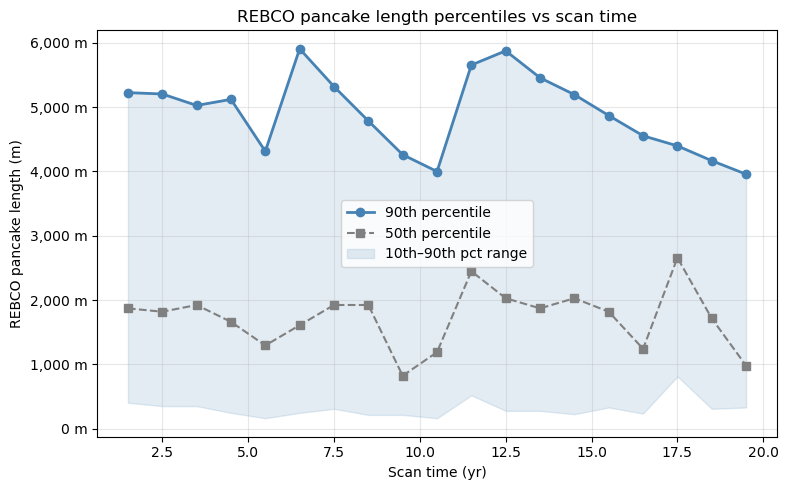

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('area_grids_L1000mm.csv')
df.columns = df.columns.str.strip()
df = df[df['converged'].astype(str).str.strip() == 'True'].copy()

df['scan_yr'] = df['scan']

# ── Filter to 1–20 years and bin ──────────────────────────────────────────────
df = df[(df['scan_yr'] >= 1) & (df['scan_yr'] <= 20)].copy()

bin_edges = np.arange(1, 21, 1)
labels    = np.arange(1, 20)
df['scan_bin'] = pd.cut(df['scan_yr'], bins=bin_edges, labels=labels, right=False)
df = df.dropna(subset=['scan_bin'])
df['scan_bin'] = df['scan_bin'].astype(int)

# ── Compute 90th percentile per bin ──────────────────────────────────────────
results = []

for scan_val in sorted(df['scan_bin'].unique()):
    group = df[df['scan_bin'] == scan_val]['rebco_pancake_length'].dropna()

    if len(group) < 3:
        print(f"  [!] Not enough data for scan = {scan_val}–{scan_val+1} yr")
        continue

    p10 = group.quantile(0.10)
    p50 = group.quantile(0.50)
    p90 = group.quantile(0.90)

    results.append({
        'scan_bin'    : f'{scan_val}–{scan_val+1}',
        'scan_yr_mid' : scan_val + 0.5,
        'n_points'    : len(group),
        'p10_m'       : round(p10, 2),
        'p50_m'       : round(p50, 2),
        'p90_m'       : round(p90, 2),
    })

    print(f"  scan={scan_val}–{scan_val+1} yr | n={len(group):4d} | "
          f"p10={p10:,.0f} m | p50={p50:,.0f} m | p90={p90:,.0f} m")

# ── Summary ───────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print("\n── Summary ──────────────────────────────────────────────────────────────")
print(results_df.to_string(index=False))
results_df.to_csv('rebco_pancake_90pct_results.csv', index=False)
print("\nSaved → rebco_pancake_90pct_results.csv")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(results_df['scan_yr_mid'], results_df['p90_m'],
        color='steelblue', marker='o', linewidth=2, label='90th percentile')
ax.plot(results_df['scan_yr_mid'], results_df['p50_m'],
        color='grey', marker='s', linewidth=1.5, linestyle='--', label='50th percentile')
ax.fill_between(results_df['scan_yr_mid'],
                results_df['p10_m'],
                results_df['p90_m'],
                alpha=0.15, color='steelblue', label='10th–90th pct range')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:,.0f} m'))
ax.set_xlabel('Scan time (yr)')
ax.set_ylabel('REBCO pancake length (m)')
ax.set_title('REBCO pancake length percentiles vs scan time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scan_vs_pancake_90pct.png', dpi=150, bbox_inches='tight')
plt.show()